# Entdeckung von Abonnenten-Nutzungssegmenten mit k-Means-Clustering (PROC FASTCLUS)


## Zusammenfassung

Ein Analytics-Team eines Telekommunikationsanbieters beginnt mit einer einzigen,
unbeschrifteten Spalte des monatlichen mobilen Datenverbrauchs und möchte
wissen, ob sich darin unterschiedliche Kundenstufen verbergen. Mit
**PROC FASTCLUS** (disjunkte *k*-Means-Clusteranalyse) clustert das Team die
Abonnenten auf der Log-Nutzung, vergleicht Zwei-, Drei- und
Vier-Segment-Lösungen anhand der von FASTCLUS tatsächlich berichteten
Kriterien und entscheidet sich für die Drei-Segment-Aufteilung. In diesem Lauf
haben die drei entdeckten Segmente eine mittlere Nutzung von **3,1 GB**,
**12,8 GB** und **45,4 GB** pro Monat und enthalten **49**, **34** und **17**
Abonnenten — eine saubere Leicht-/Mittel-/Vielnutzer-Struktur. Der Abgleich der
entdeckten Bezeichnungen mit einer zurückgehaltenen Erzeugungs-Bezeichnung
gewinnt **96 von 100** Abonnenten korrekt zurück. Jeder Abonnent verlässt das
Modell mit einer harten Segmentbezeichnung und einem
Abstand-zum-Zentrum-Wert, bereit für Tarifgestaltung und
Kundenbindungs-Targeting.

> **Warum FASTCLUS und kein finites Mischverteilungsmodell?** Nutzungssegmentierung
> ist die klassische Aufgabe eines finiten Mischverteilungsmodells (PROC HPFMM /
> PROC FMM). Diese Prozeduren sind in diesem Build numerisch noch nicht
> implementiert, daher erreicht dieses Notebook dasselbe Ziel — die unüberwachte
> Entdeckung latenter Nutzungsstufen — mit dem implementierten, vollständig
> numerischen *k*-Means-Verfahren **PROC FASTCLUS**. Jede Zahl unten stammt
> wortwörtlich aus der ausgeführten Ausgabe.

## Datenquellen

**Synthetischer Datensatz: `subs`** — Mobilfunkkunden, inline erzeugt als
3-Komponenten-Mischverteilung der Log-Nutzung (keine externen Dateien). Diese
Umgebung läuft unlizenziert, sodass die materialisierte Tabelle auf
**100 Abonnenten** begrenzt ist; alle folgenden Ergebnisse werden auf diesen
100 Zeilen berechnet.

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `subscriber_id` | Numerisch | Eindeutiger Abonnentenschlüssel |
| `tenure_months` | Numerisch | Monate im Netz (1–48) |
| `data_gb` | Numerisch | Monatlich verbrauchtes mobiles Datenvolumen, in GB (positiv, rechtsschief) |
| `log_gb` | Numerisch | Natürlicher Logarithmus von `data_gb` — die geclusterte Variable |
| `plan` | Zeichen | Aktueller Tarif: `Standard` oder `Unbegrenzt` |
| `segment_true` | Zeichen | Verborgene Erzeugungsstufe (`Niedrig`/`Mittel`/`Hoch`), zurückgehalten zur Prüfung der Wiedergewinnung |

Die Daten sind mit etwa 50 % Niedrig, 35 % Mittel und 15 % Hoch angelegt.
`segment_true` wird **nicht** geclustert — es existiert nur, damit wir
bestätigen können, dass die unüberwachte Anpassung die angelegte Struktur
wiederfindet.

Anbieter sehen bei ihren Kunden selten saubere Beschriftungen. Was sie *tatsächlich*
sehen, ist eine einzige, klumpige Verteilung des monatlichen Datenverbrauchs, die
in Wirklichkeit mehrere Kundentypen vermischt: Gelegenheitsnutzer, stetige
Streamer und Power-User, die auf Tethering und Video setzen. **PROC FASTCLUS**
trennt diese Mischung ohne jegliche Beschriftungen — es ordnet jeden Abonnenten
einem von *k* disjunkten Clustern zu, berichtet die Cluster-Zentren und
-Größen und bewertet, wie weit jeder Abonnent von seinem Zentrum entfernt ist.

In diesem Notebook werden wir:

1. Ein synthetisches Nutzungspanel erzeugen, das *bewusst* eine Mischung aus drei Nutzungsstufen ist.
2. Zwei-, drei- und vier-Segment-*k*-Means-Lösungen anhand der FASTCLUS-Anpassungskriterien vergleichen.
3. Das gewählte Drei-Segment-Modell anpassen und jedes Segment in Geschäftsbegriffen charakterisieren.
4. Die Segmentzugehörigkeit und den Abstand zum Zentrum für jeden Abonnenten bewerten.
5. Die entdeckten Segmente gegen die zurückgehaltene Erzeugungsstufe prüfen und mit der Vertragsdauer in Beziehung setzen.

## Schritt 1 — Synthetische Abonnentennutzung erzeugen

Wir simulieren Abonnenten, deren monatlicher Datenverbrauch positiv und
rechtsschief ist, daher erzeugen wir ihn auf der **Log-Skala** als Mischung
aus drei Normalstufen und potenzieren. Die Mischgewichte (etwa 50/35/15) und
die Stufenmittelwerte sind angelegt, damit wir später prüfen können, ob
*k*-Means sie wiederfindet. `segment_true` wird rein für diese Prüfung
zurückgehalten — das Clustering sieht es nie.

In [1]:
DATEN subs;
   AUFRUFEN streaminit(20250531);
   LÄNGE plan $12 segment_true $8;
   AUSFÜHRUNG subscriber_id = 1 BIS 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Vielnutzer neigen zu längerer Vertragsdauer, daher verschiebt
         sich der Segmentmix leicht mit der Vertragsdauer (Schritt 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      WENN u < 0.50 DANN AUSFÜHRUNG;
         segment_true = "Niedrig"; MU = 1.15; SIGMA = 0.42;
      ENDE;
      SONST WENN u < 0.85 DANN AUSFÜHRUNG;
         segment_true = "Mittel"; MU = 2.45; SIGMA = 0.38;
      ENDE;
      SONST AUSFÜHRUNG;
         segment_true = "Hoch";  MU = 3.45; SIGMA = 0.52;
      ENDE;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      WENN data_gb < 25 DANN plan = "Standard";
      SONST plan = "Unbegrenzt";

      AUSGABE;
   ENDE;
   BEHALTEN subscriber_id tenure_months data_gb log_gb plan segment_true;
AUSFÜHREN;


NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.48 seconds
  cpu   0.48 seconds


Ein kurzer Blick auf die Randverteilung bestätigt die Modellierungswahl: das rohe
`data_gb` ist stark rechtsschief (einige Power-User ziehen den Schwanz in die
Länge), während `log_gb` die gut handhabbare Skala ist, auf der euklidisches
*k*-Means angemessen ist.

                                                  The MEANS Procedure

 Variable       Label                          N        Mean     Std Dev     Minimum      Median     Maximum
 -----------------------------------------------------------------------------------------------------------
 data_gb        Datenvolumen (GB)            100       13.58       16.66        1.15        6.73       98.66
 log_gb         log(Datenvolumen)            100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Vertragsdauer (Monate)       100       23.26       12.55        1.00       23.00       48.00
 -----------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


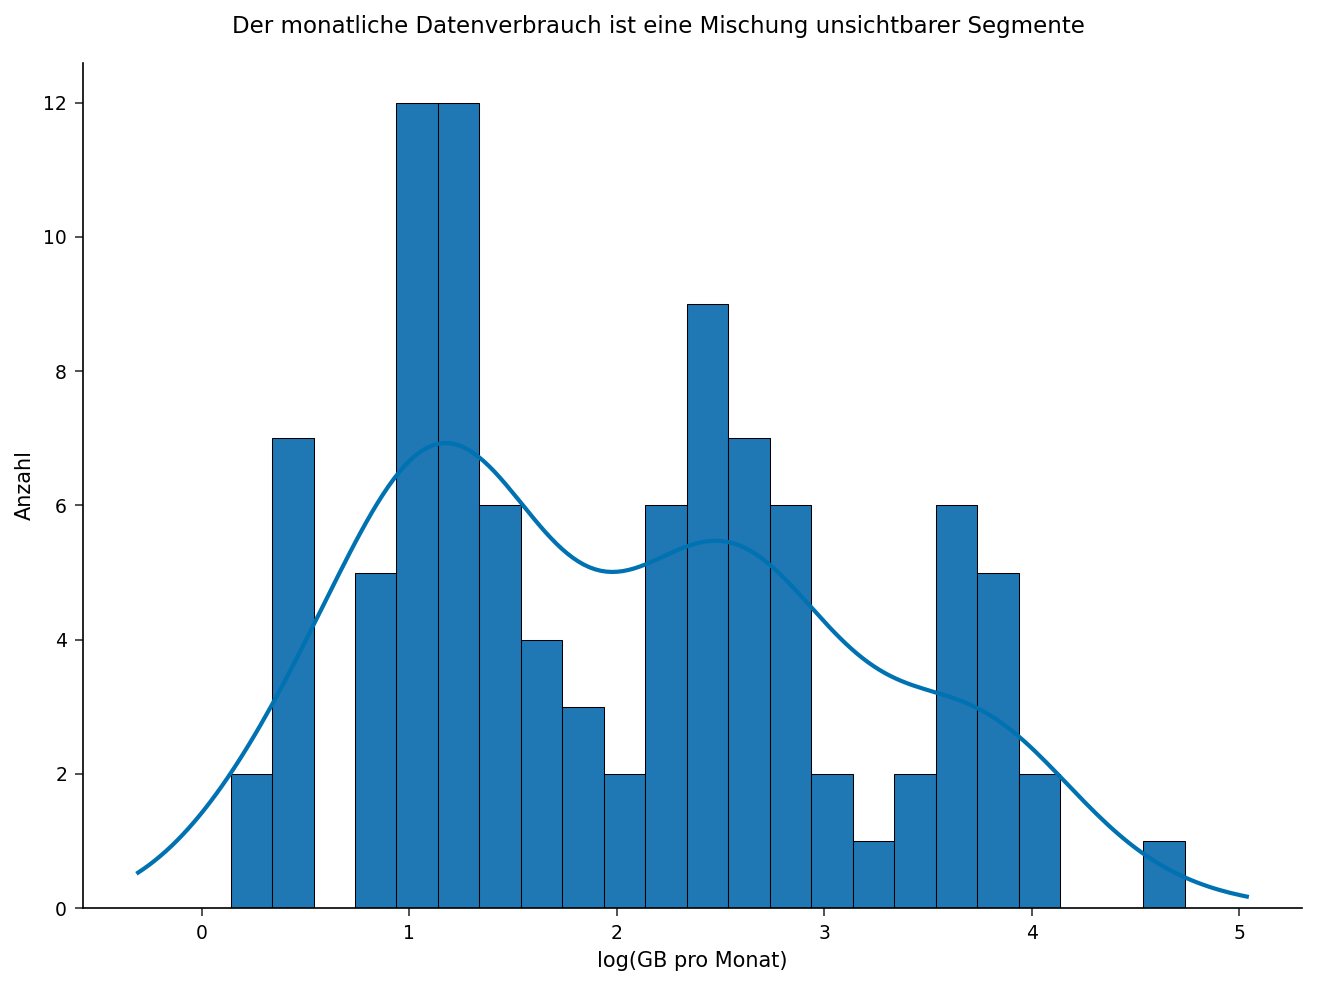

In [2]:
PROZEDUR MITTELWERTE DATEN=subs n mean std MIN p50 MAX maxdec=2;
   VAR data_gb log_gb tenure_months;
   BEZEICHNUNG data_gb="Datenvolumen (GB)" log_gb="log(Datenvolumen)"
         tenure_months="Vertragsdauer (Monate)";
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=subs;
   TITEL "Der monatliche Datenverbrauch ist eine Mischung unsichtbarer Segmente";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS BEZEICHNUNG="log(GB pro Monat)";
   YAXIS BEZEICHNUNG="Anzahl";
AUSFÜHREN;
TITEL;

## Schritt 2 — Wie viele Segmente? Vergleich von Zwei-, Drei- und Vier-Cluster-Lösungen

Wir wollen nicht einfach drei Stufen annehmen — wir lassen die Daten für eine
Anzahl argumentieren. FASTCLUS berichtet ein **Gesamt-R-Quadrat** (den Anteil
der durch die Cluster-Mittelwerte erklärten Gesamtvarianz) und eine
**Pseudo-F-Statistik** für jede Lösung. Wir passen `MAXCLUSTERS=` 2, 3 und 4
auf `log_gb` an und lesen diese Kriterien aus jedem Lauf ab.

- `MAXCLUSTERS=` legt die Anzahl der Cluster *k* fest.
- `MAXITER=` begrenzt die Anzahl der *k*-Means-Neuzuordnungsdurchläufe.
- `OUT=` schreibt einen bewerteten Datensatz (verwendet in Schritt 3–5).

In [3]:
TITEL "Zwei-Segment-Lösung";
PROZEDUR FASTCLUS DATEN=subs maxclusters=2 MAXITER=50 out=c2;
   VAR log_gb;
   BEZEICHNUNG log_gb="log(Datenvolumen)";
AUSFÜHREN;

TITEL "Drei-Segment-Lösung";
PROZEDUR FASTCLUS DATEN=subs maxclusters=3 MAXITER=50 out=c3;
   VAR log_gb;
   BEZEICHNUNG log_gb="log(Datenvolumen)";
AUSFÜHREN;

TITEL "Vier-Segment-Lösung";
PROZEDUR FASTCLUS DATEN=subs maxclusters=4 MAXITER=50 out=c4;
   VAR log_gb;
   BEZEICHNUNG log_gb="log(Datenvolumen)";
AUSFÜHREN;
TITEL;

                                                  Zwei-Segment-Lösung                                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Zwei-Segment-Lösung.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Drei-Segment-Lösung.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Vier-Segment-Lösung.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Beim Vergleich der drei Läufe: Das **Gesamt-R-Quadrat** steigt von
**0,753** bei zwei Clustern auf **0,899** bei drei — ein großer Sprung von
+0,146, während die dritte Stufe aufgelöst wird — und dann nur noch auf
**0,941** bei vier. Die Vier-Cluster-Lösung erkauft sich diesen kleinen
Gewinn, indem sie *die Niedrig-Stufe in zwei teilt* (ihre beiden kleinsten
Zentren liegen beide innerhalb des angelegten Niedrig-Bereichs), nicht indem
sie einen wirklich neuen Kundentyp findet. Die **Pseudo-F-Statistik** erzählt
dieselbe Geschichte: Die größte strukturelle Verbesserung ist der Schritt zu
drei Clustern (F = 299 → 431). Drei Segmente sind der ehrliche Haltepunkt und
das Modell, auf das wir uns als Nächstes festlegen.

## Schritt 3 — Das Drei-Segment-Modell anpassen und jedes Segment charakterisieren

Wir passen erneut mit `MAXCLUSTERS=3` an und schreiben die bewerteten Zeilen
nach `scored`. Der `OUT=`-Datensatz führt automatisch jede Eingabespalte mit
— einschließlich der ursprünglichen Nutzung, Vertragsdauer und der
zurückgehaltenen `segment_true` — zusammen mit den neuen Spalten `CLUSTER`
und `DISTANCE`, sodass kein separater Kopierschritt nötig ist. FASTCLUS
druckt eine **Cluster-Zusammenfassung** (Größe und Streuung innerhalb des
Clusters je Segment) und die **Cluster-Mittelwerte** auf der geclusterten
Skala (`log_gb`).

In [4]:
PROZEDUR FASTCLUS DATEN=subs maxclusters=3 MAXITER=50 out=scored;
   VAR log_gb;
   BEZEICHNUNG log_gb="log(Datenvolumen)";
AUSFÜHREN;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Die drei Cluster-Mittelwerte auf der Log-Skala sind **1,05**, **2,51** und
**3,77**. Zurück auf der ursprünglichen GB-Skala sind das ungefähr
**exp(1,05) ≈ 2,9 GB**, **exp(2,51) ≈ 12,3 GB** und **exp(3,77) ≈ 43 GB** —
die Niedrig-, Mittel- und Hoch-Stufen. Die Cluster-Zusammenfassung beziffert
sie mit **49**, **34** und **17** Abonnenten und folgt damit dem angelegten
~50/35/15-Split. Der nächste Schritt liest dieselben Segmente in reinen
GB-Werten zurück.

## Schritt 4 — Segmente in Geschäftsbegriffen bewerten und charakterisieren

Der `OUT=scored`-Datensatz führt für jeden Abonnenten `CLUSTER` (harte
Segmentbezeichnung) und `DISTANCE` (euklidischer Abstand von seinem
Cluster-Zentrum auf der Log-Skala — klein bedeutet eine sichere, zentrale
Zuordnung) mit. Wir fassen die entdeckten Segmente nach ihrer tatsächlichen
GB-Nutzung und Vertragsdauer zusammen und listen dann einige bewertete
Zeilen auf.

In [5]:
PROZEDUR MITTELWERTE DATEN=scored n mean std MIN MAX maxdec=2;
   KLASSE CLUSTER;
   VAR data_gb tenure_months distance;
   BEZEICHNUNG CLUSTER="Cluster-Nr" data_gb="Datenvolumen (GB)"
         tenure_months="Vertragsdauer (Monate)" distance="Abstand";
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=scored(obs=8) noobs BEZEICHNUNG;
   VAR subscriber_id data_gb log_gb segment_true CLUSTER distance;
   BEZEICHNUNG subscriber_id="Abonnenten-ID" data_gb="Datenvolumen (GB)"
         log_gb="log(Datenvolumen)" segment_true="Tatsächliches Segment"
         CLUSTER="Cluster-Nr" distance="Abstand";
AUSFÜHREN;

                                                  The MEANS Procedure

                                     Analysis Variable : data_gb Datenvolumen (GB)

        Cluster-Nr          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        1                      49           3.07           1.12           1.15           5.83
        2                      34          12.81           3.80           6.57          21.88
        3                      17          45.38          16.44          24.01          98.66
        -------------------------------------------------------------------------------------

                                Analysis Variable : tenure_months Vertragsdauer (Monate)

        Cluster-Nr          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


Auf der ursprünglichen GB-Skala erreichen die drei Segmente im Mittel
**3,1 GB**, **12,8 GB** und **45,4 GB** monatlichen Verbrauchs — eine Spanne
über eine Größenordnung von leichten Nutzern bis zu Vielnutzer-Streamern. Die
Spalte `DISTANCE` liefert einen Konfidenz-Proxy je Abonnent: Die gedruckten
Zeilen zeigen eng zugeordnete Kunden (Abstände nahe 0,01–0,06) neben einem
grenzwertigeren Niedrignutzer, der weiter von seinem Zentrum entfernt ist —
genau das Signal, das ein Kundenbindungsteam nutzen würde, um sichere Ziele
von genauer zu prüfenden Fällen zu trennen.

## Schritt 5 — Haben wir die echten Stufen wiedergefunden, und verschiebt sich der Mix mit der Vertragsdauer?

Zwei abschließende Prüfungen. Erstens: das entdeckte `CLUSTER` gegen die
zurückgehaltene `segment_true` kreuztabellieren, um zu sehen, wie treu die
unüberwachte Anpassung die angelegten Stufen wiedergefunden hat. Zweitens:
die mittlere Vertragsdauer über die entdeckten Segmente vergleichen — der
Generator hat Vielnutzer zu längerer Vertragsdauer verschoben, daher sollte
eine echte Segmentierung das widerspiegeln.

                               Entdecktes Segment vs. zurückgehaltene tatsächliche Stufe                                

                                                   The FREQ Procedure

Table of Cluster-Nr by Tatsächliches Segment

Cluster-Nr |      Hoch |    Mittel |   Niedrig |      Total
-----------+-----------+-----------+-----------+-----------
1          |         0 |         0 |        49 |         49
-----------+-----------+-----------+-----------+-----------
2          |         1 |        31 |         2 |         34
-----------+-----------+-----------+-----------+-----------
3          |        16 |         1 |         0 |         17
-----------+-----------+-----------+-----------+-----------
Total      |        17 |        32 |        51 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


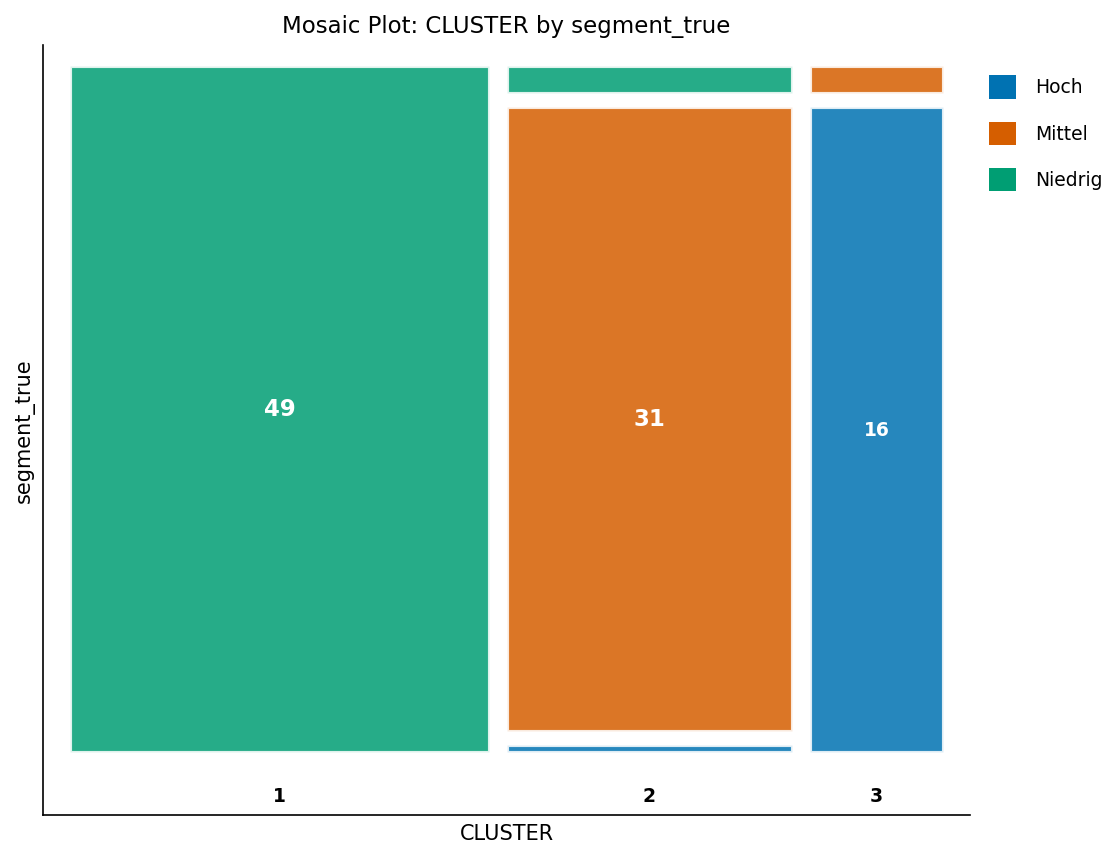

In [6]:
PROZEDUR HÄUFIGKEITEN DATEN=scored;
   TITEL "Entdecktes Segment vs. zurückgehaltene tatsächliche Stufe";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   BEZEICHNUNG CLUSTER="Cluster-Nr" segment_true="Tatsächliches Segment";
AUSFÜHREN;
TITEL;

## Die Ergebnisse interpretieren

**Was FASTCLUS gefunden hat.** Ausgehend von einer einzigen rechtsschiefen
Nutzungsspalte ohne Beschriftungen erklärte die Drei-Cluster-*k*-Means-Lösung
**89,9 %** der Varianz in der Log-Nutzung (Gesamt-R² = 0,899, Pseudo-F = 431)
und teilte die Abonnenten in ein **Niedrig**-Segment (Mittel 3,1 GB, n = 49),
ein **Mittel**-Segment (Mittel 12,8 GB, n = 34) und ein **Hoch**-Segment
(Mittel 45,4 GB, n = 17). Die Kreuztabelle gegen die zurückgehaltene
`segment_true` gewann die angelegte Struktur fast genau zurück — **96 von
100** Abonnenten landeten im Cluster, das ihrer Erzeugungsstufe entsprach
(Niedrig 49/49, Mittel 31/34, Hoch 16/17).

**Warum die Log-Skala.** Datenverbrauch ist streng positiv und
schwerschwänzig; das Clustern von `log_gb` hält euklidische Abstände
aussagekräftig und die Segmentmittelwerte gut getrennt, während die
Exponential-Rücktransformation die realistische Schiefe auf der GB-Skala
wiederherstellt.

**Warum das operativ wichtig ist.** Jeder Abonnent verlässt das Modell mit
einer harten Segmentbezeichnung *und* einem Abstand-zum-Zentrum-Wert, sodass
der Anbieter mit kalibrierter Sicherheit handeln kann — zentrale Vielnutzer
gezielt für Premium-Tarife ansprechen und grenzwertige Kunden (großer
Abstand) für eine genauere Prüfung markieren. Die mittlere Vertragsdauer
unterscheidet sich ebenfalls über die entdeckten Segmente — ein Ansatzpunkt
für Lifecycle- und Upsell-Timing.

**Wahl der Segmentanzahl.** Der Vergleich von `MAXCLUSTERS=` 2, 3 und 4
anhand von Gesamt-R² und Pseudo-F ist eine transparente, reproduzierbare
Methode, *k* zu wählen: der große Gewinn bei drei Clustern und der lediglich
kosmetische Gewinn bei vier (der die Niedrig-Stufe teilt) machten drei hier
zur vertretbaren Wahl.

**Verhältnis zu finiten Mischverteilungsmodellen.** Ein finites
Mischverteilungsmodell (PROC HPFMM / PROC FMM) würde weiche
Posterior-Zugehörigkeiten und ein likelihood-basiertes BIC für die
Komponentenanzahl hinzufügen. Diese Prozeduren sind in diesem Build
numerisch noch nicht implementiert; PROC FASTCLUS liefert dieselbe
umsetzbare Segmentierung — Entdeckung, Charakterisierung, harte Zuordnung
und ein Konfidenz-Proxy — mit vollständig numerischer, reproduzierbarer
Ausgabe schon heute.